# Sección De Hiperparámetros

En esta sección se definen diferentes costantes a utilizar durante el entrenamiento y validación de la red neuronal.
Entre ellos, se destacan los porcentajes de segmentación del dataset de imágenes utilizado, además de parámetros del
modelo como la tasa de aprendizaje, paciencia del planificador, número de épocas de entrenamiento y validación entre
otros.

In [26]:
# Sección de hiperparámetros
# ------------------------------------

DATASET_PERCENT = 1
TRAIN_PERCENT = 0.7
VAL_PERCENT = 0.2
TEST_PERCENT = 0.1
IMAGE_SIZE = 128
BATCH_SIZE = 64
LEARNING_RATE = 0.0005
SCHEDULER_PATIENCE = 5
MOMENTUM = 0.9
NUM_EPOCH = 50
CONV_KERNEL_SIZE = 7
CONV_PADDING_SIZE = 3
POOL_KERNEL_SIZE = 2
POOL_PADDING_SIZE = 0
DROPOUT_1 = 0.6
DROPOUT_2 = 0.75

# Dataset utilizado, carga y demostración.

Para el entrenamiento de la red neuronal se ha utilizado un dataset extraído de la página web <a href="https://www.kaggle.com/">
Kaggle </a>. Concrétamente, hemos empleado el dataset de imágenes llamado **Natural Images** de Prasun Roy. Tal como describe la
propia página, el dataset contiene 6899 imágenes de 8 clases diferentes recopiladas de diversas fuentes. Las clases a clasificar
corresponden a los siguientes objetos: aviones, coches, gatos, perros, flores, frutas, motocicletas y personas. El dataset usado
data del año 2018.

Tras descargar el conjunto de imágenes y crear un nuevo dataset, procedemos a segmentar el mismo en tres subconjuntos utilizados
para los procesos de entrenamiento, validación y test. Para ello, declararamos un array de índices desordenados que servirá como
base para seleccionar que imágenes pertenecerán a cada uno de los suconjuntos. En dicha selección, los hiperparámetros definidos
para estipular el tamaño de cada subconjunto juegan un papel fundamental.

A continuación, con motivo de mejorar ligéramente el overfitting de la red neuronal, es decir, el sobreajuste a los datos usados
en el entrenamiento, se aplican técnicas de Data Augmentation al completo de imágenes de los tres subconjuntos. Dichas técnicas
incluyen transformaciones sobre un eje de la imágen, rotaciones, etc. Además, se transforman a tensor compatible con el entorno
de trabajo Pytorch y sufren un proceso de normalización de cada uno de los píxeles a un rango fijo de valores entre menos uno y
uno.

Por último, se crean los objetos **Data Loaders** encargados de introducir los tensores que constituyen las diferentes imágenes en
la red neuronal. Dichos objetos inyectarán las imágenes de uno de los subconjuntos según corresponda, en diversos lotes con tamaño
fijo según dicta el hiperparámetros _BATCH_SIZE_.

In [28]:
import kagglehub
import torch
import random
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

"""
La siguiente sección de código introduce técnicas de Data Augmentation que
se aplicarán a las imágenes del dataset antes de introducirlas en la red neuronal.
"""

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), # Ajustamos el tamaño
    transforms.RandomHorizontalFlip(p = 0.5),    # Flip Horizontal
    transforms.RandomRotation(degrees = 20),     # Rotación
    transforms.ToTensor(),                       # Transformación a tensor
    transforms.Normalize((0.5, ), (0.5, ))       # Normalización
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), # Ajustamos el tamaño
    transforms.ToTensor(),                       # Transformación a tensor
    transforms.Normalize((0.5, ), (0.5, ))       # Normalización
])

"""
Conformamos la ruta al dataset y lo descargamos. Hemos utilizado el dataset
'Natural Images' de Prasun Roy, obtenido de la página Kaggle.
"""

path = kagglehub.dataset_download("prasunroy/natural-images")
train_path = os.path.join(path, "natural_images")
print("Path to dataset files: ", train_path)

"""
Cargamos el dataset para su uso con el framework de PyTorch. Para comprobar
la carga, imprimimos el nombre de las clases existenten en el dataset. Como
se necesitará más adelante, se declara el número de clases encontrado.
"""

dataset = datasets.ImageFolder(root = train_path)
print("Classes: ", dataset.classes)
num_classes = len(dataset.classes)

"""
A partir de este punto comienza el proceso de subdivisión del dataset en
diferentes partes para el entrenamiento, validación y test.

1. Se selecciona un subconjunto del dataset de imágenes total.
2. Se declara un array desordenado de índices igual al tamaño del subconjunto.
3. Se declaran los tamaños de los tres subconjuntos a dividir.
4. Se realiza la división del array de índices según los tamaños calculados.
5. Se crean los subsets de entrenamiento, validación y test.
"""

# Primer paso
subset_size = int(len(dataset) * DATASET_PERCENT)
subset_indexes = random.sample(range(len(dataset)), subset_size)
subset = Subset(dataset, subset_indexes)

# Segundo paso
indexes = list(range(len(subset)))
random.shuffle(indexes)

# Tercer paso
train_size = int(len(subset) * TRAIN_PERCENT)
val_size = int(len(subset) * VAL_PERCENT)
test_size = len(subset) - train_size - val_size

# Cuarto paso
train_indexes = indexes[:train_size]
val_indexes = indexes[train_size:train_size + val_size]
test_indexes = indexes[train_size + val_size:]

# Quinto paso
train_subset = Subset(dataset, train_indexes)
val_subset = Subset(dataset, val_indexes)
test_subset = Subset(dataset, test_indexes)

"""
Debemos aplicar las trasnformaciones declaradas al inicio a los diferentes
subconjuntos según corresponda.
"""

train_subset.dataset.transform = train_transform
val_subset.dataset.transform = val_test_transform
test_subset.dataset.transform = val_test_transform

"""
A continuación, creamos los objetos DataLoaders para cada uno de los
subconjuntos, encargados de introducir los datos a la red neuronal.
"""

train_loader = DataLoader(
    train_subset,
    batch_size = BATCH_SIZE,
    shuffle = True
)

validation_loader = DataLoader(
    val_subset,
    batch_size = BATCH_SIZE,
    shuffle = False
)

test_loader = DataLoader(
    test_subset,
    batch_size = BATCH_SIZE,
    shuffle = False
)

"""
Para finalizar la sección de carga y preparación de datos, se inspecciona
el subset de entrenamiento en busqueda del valor máximo y mínimo de los
pixeles normalizados de la primera imagen.
"""
print("Máximo valor de la imagen:", train_subset[0][0].squeeze().max())
print("Mínimo valor de la imagen:", train_subset[0][0].squeeze().min())

Path to dataset files:  C:\Users\adria\.cache\kagglehub\datasets\prasunroy\natural-images\versions\1\natural_images
Classes:  ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']
Máximo valor de la imagen: tensor(0.7176)
Mínimo valor de la imagen: tensor(-0.9294)


# Visualización De Imágenes

Tras finalizar el trabajo de carga y división, se muestran a continuación un conjunto del total de imágenes disponibles en el dataset
utilizado. En total se muestran 10 imágenes divididas en dos filas y cinco columnas, acompañadas, en orden, de las etiquetas o clases
de cada una de las imágenes de muestra, observables en la parte superior. Las imágenes cambian dinámicamente con cada carga del dataset
de datos.

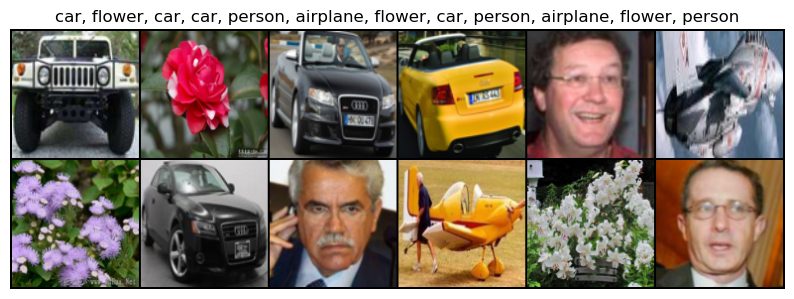

In [30]:
import matplotlib.pyplot as plt
import torch
from torchvision.utils import make_grid

# Función para visualizar imágenes del DataLoader
def visualize_dataset(dataloader, class_names, num_images=12):
    """
    Muestra un conjunto de imágenes con sus etiquetas.

    Args:
        dataloader: DataLoader con el dataset.
        class_names: Lista de nombres de las clases.
        num_images: Número de imágenes a mostrar.
    """
    # Obtener un batch de imágenes
    images, labels = next(iter(dataloader))

    # Seleccionar solo las primeras num_images imágenes
    images = images[:num_images]
    labels = labels[:num_images]

    # Desnormalizar las imágenes (si fueron normalizadas)
    images = images * 0.5 + 0.5  # Deshacer Normalización (-1 a 1 => 0 a 1)

    # Crear un grid de imágenes
    grid_img = make_grid(images, nrow=6, padding=2)
    np_grid = grid_img.numpy().transpose((1, 2, 0))  # Convertir a formato de Matplotlib

    # Mostrar las imágenes
    plt.figure(figsize=(10, 5))
    plt.imshow(np_grid)
    plt.axis('off')

    # Mostrar etiquetas
    labels_text = [class_names[label] for label in labels]
    plt.title(", ".join(labels_text), fontsize=12)
    plt.show()

class_names = dataset.classes  # Cambia esto por las clases reales
visualize_dataset(test_loader, class_names)

# Modelo De Red Convolucional

Un modelo de red convolucional es un tipo de red neuronal caracterizada principalmente por poseer y emplear dos tipos de
capas diferenciadas estructural y funcionalmente. Cada tipo de capa ejecuta una labor específica en el objetivo final de
la red, sin embargo, actuan de forma complementaria. Son aplicables a diferentes campos, como el procesamiento de texto
y lenguaje natural, el procesamiento de audio, etc. Sin embargo, de acuerdo a la tarea planteada en esta práctica, vamos
a abordar la explicación focalizándonos en el tratamiento de imágenes para su posterior clasificación.

En primer lugar encontramos las **capas de convolución** o capas convolutivas, llamadas así por la operación matemática que
realizan sobre los píxeles de la imagen o sobre los mapas de características. Principalmente, están al cargo de extraer las
características o patrones de relevancia de las imagenes para poder posteriormente clasificarlas. Para ello, realizan, como
se ha comentado, una operación llamada convolución, resultante de aplicar una combinación entre los píxeles de la imagen o
mapa de características con una máscara o núcleo dando lugar a un único pixel. Con la repetición secuencial de dicha labor
sobre el conjunto de píxeles de una imágen, se forman las determinadas capas de características, que incorporarán, de forma
sucesiva, los rasgos de relevancia que ayuden a la red a realizar la clasificación. El número de núcleos utilizados conforma
el número de canales o mapas de características que salgan de una capa de convolución. Dichos canales se corresponden con la
entrada de la siguiente capa de convolución o se aplanan conviertiéndose en la entrada de las capas de clasificación finales.

En segundo lugar, encontramos las **capas de clasificación** o capas _vanilla_, cuya función es clasificar las características
resultantes de aplicar las diferentes capas de convolución. Al igual que las capas de convolución ajustan de froma dinámica el
total de los pesos encontrados en las máscaras o kernels de los diferentes canales, estas capas también ajustan los diferentes
pesos de interconexionado con el objetivo de reducir al máximo el error cometido al realizar la clasificación de los datos. Se
ha utilizado, como se describirá más adelante, una función de error basada en la distribución de probabilidad de pertenencia a
una clase determinada para el conjunto de las imágenes de prueba. Además, el método de ajuste del error empleado constituye una
variante al método del descenso por gradiente habitual, llamado descenso por gradiente estocástico sobre el cual profundizaremos
más adelante.

De manera adicional, se incluyen una serie de capas de relativa importancia, entre las que se incluyen capas de pooling, capas de
normalización y capas de dropout, cada una con un cometido específico que vamos a explicar a continuación.

* Capas de pooling: se trata de un elemento fundamental en toda red convolutiva, cuyo principio se basa en la reducción en tamaño
  de los diferentes mapas de características que fluyan por el conjunto de capas de convolución. Reducir el tamaño de estos mapas
  proporciona la ventaja de inferir, con núcleos o mascaras equivalentes a las utilizadas en capas anteriores, a una cantidad de
  información relevante mayor de la imágen original en capas posteriores. Gracias a ello, la red es capaz de mejorar su eficiencia
  en la detección de estos patrones o características. La operación utiliza otro núcleo de tamaño determinado, selecciando de todo
  el espacio del mapa de características ocupado por dicho núcleo, el valor más relevante.

* Capas de normalización: la funcionalidad de esta capa reside en normalizar los valores de salida de los diferentes canales de una
  capa de convolución a un determinado valor reduciendo el cambio de distribución interna. Para ello, se tienen en cuenta la media
  y varianza de dichos valores. Ayudan de manera sustancia a mantener el equilibrio del modelo durante el entrenamiento y a reducir
  el riesgo de sufrir overfitting.

* Capas de dropout: una capa de dropout tiene como tarea desactivar aleatoriamente, de acuerdo a una cierta probabilidad, un número
  determinado de neuronas cuyos valores entran a la siguiente capa con el fin de proporcionar al modelo una menor sensibilidad a las
  características específicas de los datos de entrenamiento. Como resultado, se produce una disminución del riesgo de overfitting.

En el código se incluye una descripción de cada una de las capas que forman el modelo siendo siempre de uno de los tipos versados en
esta descripción. De manera adicional, se quiere comentar sobre la función de activación utilizada tanto para las capas lineales como
para las capas de convolución. El objetivo principal de una función de activación es introducir distorsiones no lineales en la salida
de las neuronas ante la naturaleza lineal de su operatividad. Si dispusieramos de una red neuronal sin funciones de activación, todas
las operaciones realizadas convergerían y colapsarían en una sola operación lineal, por lo que se deben de introducir distorsiones de
forma que estas posibiliten el interconexionado de neuronas en diferentes capas. Esta función de activación concreta, llamada también
unidad lineal rectificada, tiene como objetivo convertir valores logit (h) en 0 si estos son negativos o, sin modificar, si estos son
positivos.

In [32]:
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

"""
Definición del modelo de red neuronal convolucional.
"""

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        """
        Aquí se definen las capas de la red neuronal.

        Lista de capas del modelo:

        Capas de convolución y pooling.
        -------------------------------------------------------------------
        1. Capa de convolución de 3 canales de entrada a 32 canales de
        salida de tamaño 128 * 128.
        2. Capa de normalización de las entradas a capas posteriores de
        32 canales.
        3. Capa de pooling de 32 canales de entrada a 32 canales de
        salida de tamaño 64 * 64.

        4. Capa de convolución de 32 canales de entrada a 64 canales de
        salida de tamaño 64 * 64.
        5. Capa de normalización de las entradas a capas posteriores de
        64 canales.
        6. Capa de pooling de 64 canales de entrada a 64 canales de
        salida de tamaño 32 * 32.
        
        7. Capa de convolución de 64 canales de entrada a 64 canales de
        salida de tamaño 32 * 32.
        8. Capa de normalización de las entradas a capas posteriores de
        64 canales.
        9. Capa de pooling de 64 canales de entrada a 64 canales de
        salida de tamaño 16 * 16.

        10. Capa de convolución de 64 canales de entrada a 128 canales de
        salida de tamaño 16 * 16.
        11. Capa de normalización de las entradas a capas posteriores de
        128 canales.
        12. Capa de pooling de 128 canales de entrada a 128 canales de
        salida de tamaño 8 * 8.

        Capas de dropout y clasificación:
        -------------------------------------------------------------------
        1. Capa de clasificación de 128 canales de entrada de 8 * 8 a
        salida de 512 neuronas.
        2. Capa de dropout para la desactivación aleatoria de neuronas
        con un porcentaje igual a 0.6.
        3. Capa de clasificación de 512 neuronas de entrada a salida de
        256 neuronas.
        4. Capa de dropout para la desactivación aleatoria de neuronas
        con un porcentaje igual a 0.75.
        5. Capa de clasificación de 256 neuronas de entrada a salida de
        neuronas igual al número de clases.
        """

        self.conv1 = nn.Conv2d(
            in_channels = 3,
            out_channels = 32,
            kernel_size = CONV_KERNEL_SIZE,
            padding = CONV_PADDING_SIZE
        )
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(
            in_channels = 32,
            out_channels = 64,
            kernel_size = CONV_KERNEL_SIZE,
            padding = CONV_PADDING_SIZE
        )
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(
            in_channels = 64,
            out_channels = 64,
            kernel_size = CONV_KERNEL_SIZE,
            padding = CONV_PADDING_SIZE
        )
        self.bn3 = nn.BatchNorm2d(64)
        
        self.conv4 = nn.Conv2d(
            in_channels = 64,
            out_channels = 128,
            kernel_size = CONV_KERNEL_SIZE,
            padding = CONV_PADDING_SIZE
        )
        self.bn4 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(
            kernel_size = POOL_KERNEL_SIZE,
            padding = POOL_PADDING_SIZE
        )

        self.fc1 = nn.Linear(in_features = 128 * 8 * 8, out_features = 512)
        self.dropout1 = nn.Dropout(p = DROPOUT_1)
        self.fc2 = nn.Linear(in_features = 512, out_features = 256)
        self.dropout2 = nn.Dropout(p = DROPOUT_2)
        self.fc3 = nn.Linear(in_features = 256, out_features = num_classes)

    def forward(self, x):
        """
        Aquí se definen las operaciones realizadas.
        """
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.view(-1, 128 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# Bucle De Entrenamiento y Evaluación

En la próxima sección de código, se realiza el proceso de entrenamiento y evaluación del modelo de red convolucional recién creado.
Para ello, es necesario declarar una serie de parámetros claves encargados de guiar al proceso de entrenamiento y evaluación con el
objetivo de tomar decisiones que favorezcan la obtención de buenas predicciones. Entre estos parámetros se encuentran la función de
perdida utilizada en el proceso de entrenamiento de la red, el tipo de optimizador para el ajuste de los parámetros, en nuestro caso,
descenso por gradiente estocástico y un scheduler o planificador, encargado de modificar la tasa de aprendizaje según una determinada
condición. Describimos con un poco más de profundidad cada uno de estos objetos.

* Función de perdida o criterion: debido a la naturaleza del problema planteado, consistente en la clasificación de imágenes, es útil
  utilizar la función de pérdida basada en la entropía cruzada. Podemos definir la entropía, de forma simplificada, como una medición
  de la incertidumbre de un evento. Cuanto más alta sea la entropía, mayor será la incertidumbre con respecto a la distribución de
  probabilidad utilizada. Por el contrario, con una entropía menor, la incertidumbre bajará y las predicciones realizadas tendrán más
  certeza. Además, la propia administración de la función de error por la librería de PyTorch proporciona la implementación de Softmax
  para la distribución probabilística de las salidas de la red neuronal. De esta manera, con esta función de perdida permitimos medir
  la discrepancia entre las predicciones del modelo y las clases reales.

* Tipo de optimizador utilizado: como optimizador para reajustar los pesos de las diferentes capas del modelo, se utiliza la tácnica de
  descenso por el gradiente estocástico. Se trata de una variante del descenso por el gradiente tradicional, así que partiremos con la
  explicación de dicha técnica. El descenso por el gradiente permite reducir la tasa de error en las prediciones realizadas por la red
  utilizando como vía la función de error utilizada y dirimiendo que responsabilidad tiene en dicho error cada uno de los parámetros
  ajustables de la red que se relacionan con la función de error. En función de dicha responsabilidad, se dirige la obtención de nuevos
  parámetros a aquellos que minimicen dicha función de error, siendo fundamental la utilización del gradiente para realizar el descenso
  hacia cotas de errores menores, además de un parámetro conocido como tasa de aprendizaje. El descenso por el gradiente estocástico se
  caracteriza por incorporar el concepto de momento. El momento ayuda a evitar mínimos locales en la función de error utilizando inercia
  de tal manera que, en regiones donde el gradiente cambie rápidamente, se suavizará la dirección de dicho gradiente, avanzando de forma
  más lenta hacia nuevos mínimos en la función de error. Por otro lado, cuando el gradiente sea muy estable en cuanto a valor, acumulará
  el efecto de los gradientes previos ayudando a progresar hacia los mínimos más rápidamente. De tal manera, se robusteze la forma en la
  que la red neuronal realiza su aprendizaje.

* Planificador: se ha utilizado un planificador o scheduler encargado de monitorizar el error de las sucesivas evaluaciones realizadas en
  el bucle de entrenamiento y evaluación. De esta forma, cuando el planificador detecte una cierta cantidad de épocas en las que el error
  de evaluación no disminuye, el learning rate o tasa de aprendizaje se verá reducida a un 20% de su valor actual. De esta forma, se guía
  al modelo hacia una mejor solución, siendo capaz de evitar posibles mínimos locales u oscilaciones durante el aprendizaje.

Durante el proceso de entrenamiento y validación se recogen diferentes métricas para cada una de las épocas. Éstas nos ayudarán a obtener
unas conclusiones tras la finalización del entrenamiento y validación. Para cada época, todas las imágenes incluidas en el subconjunto de
entrenamiento pasa por el modelo con fin de su ajuste. Además, de forma complementaria, podemos verificar y evaluar dichos ajustes pues,
tras el proceso de entrenamiento, todas las imagenes del subconjunto de evaluación pasan por el modelo sin objetivo de aprendizaje. Para
cada uno de estos procesos se recogen, como se ha comentado, valores de acierto y de pérdida, como el error medio por lote, el número de
imágenes clasificadas corréctamente, la precisión de cada etapa, etc. Además de visualizar dichas métricas por pantalla durante el proceso
de entrenamiento, para las cuáles se incluyen descripciones adjuntas al código, mostraremos para finalizar una tabla que relaciones estos
valores y concluiremos con una descripción que favorezca su comprensión.

In [34]:
"""
Iniciación de parámetros claves para el entrenamiento.

1. Instanciación del modelo
2. Declaración de la función de pérdida
3. Declaración del optimizador - Descenso por gradiente estocástico
4. Cambio dinámico del factor de aprendizaje mediante un scheduler.
"""

model = ConvNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = LEARNING_RATE, momentum = MOMENTUM)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = "min", factor = 0.2, patience = SCHEDULER_PATIENCE)


"""
Declaración de dos estructuras para almacenar la pérdida y preción
de cada una de las épocas del entrenamiento y validación.
"""

train_accuracies = []
train_losses = []
val_accuracies = []
val_losses = []

"""
Bucle de entrenamiento y evalución de la red neuronal.

Durante el entrenamiento, la red convolucional realiza las siguientes funciones:

1. Limpieza de los gradientes de anteriores predicciones.
2. Inyección de las imagenes en el interior de la red.
3. Cálculo de la pérdida.
4. Retropropagación de la pérdida.
5. Actualización de los parámetros.

Durante la evaluación, la red convolucional realiza las siguientes funciones:
"""

for epoch in range(NUM_EPOCH):
    running_loss = 0.0 # Acumulación de la perdida de cada lote
    correct_train = 0  # Número de imagenes entrenadas corréctamente
    total_train = 0    # Total de imágenes entrenadas
    model.train()

    # Bucle de entrenamiento
    for i, (images, labels) in enumerate(train_loader, 1):
        # Ajuste de la red para cada lote de imágenes
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # Actualización de las métricas de seguimiento
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        if not i % 10:
            print(f"Epoch: {epoch}, Batch: {i}, Correct Trained: {correct_train}, Total Trained: {total_train}")
    
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train
    train_accuracies.append(train_accuracy)
    train_losses.append(train_loss)

    # Bucle de evaluación
    correct = 0    # Número de imágenes identificadas corréctamente
    total = 0      # Número de imágenes evaluadas en total
    val_loss = 0.0 # Acumulación de la pérdida de cada lote
    model.eval()
    with torch.no_grad():
        for (images, labels) in validation_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(validation_loader)
    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    # Mostrar estadísticas por época
    print(
        f'Epoch {epoch+1}/{NUM_EPOCH}, '
        f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, '
        f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%'
    )

Epoch: 0, Batch: 10, Correct Trained: 85, Total Trained: 640
Epoch: 0, Batch: 20, Correct Trained: 202, Total Trained: 1280
Epoch: 0, Batch: 30, Correct Trained: 350, Total Trained: 1920
Epoch: 0, Batch: 40, Correct Trained: 518, Total Trained: 2560
Epoch: 0, Batch: 50, Correct Trained: 733, Total Trained: 3200
Epoch: 0, Batch: 60, Correct Trained: 989, Total Trained: 3840
Epoch: 0, Batch: 70, Correct Trained: 1230, Total Trained: 4480
Epoch 1/50, Train Loss: 1.9102, Train Accuracy: 28.85%, Val Loss: 1.5018, Val Accuracy: 62.15%
Epoch: 1, Batch: 10, Correct Trained: 275, Total Trained: 640
Epoch: 1, Batch: 20, Correct Trained: 563, Total Trained: 1280
Epoch: 1, Batch: 30, Correct Trained: 867, Total Trained: 1920
Epoch: 1, Batch: 40, Correct Trained: 1210, Total Trained: 2560
Epoch: 1, Batch: 50, Correct Trained: 1560, Total Trained: 3200
Epoch: 1, Batch: 60, Correct Trained: 1917, Total Trained: 3840
Epoch: 1, Batch: 70, Correct Trained: 2275, Total Trained: 4480
Epoch 2/50, Train Los

# Gráfica Y Explicación De Los Resultados

Como se puede apreciar, en el siguiente gráfico relacionamos las métricas de entrenamiento y validación, correspondientes a la precisión
de acierto y error obtenido en cada una de las fases para el conjunto de épocas establecido.

A grandes rasgos, se ha conseguido el principal objetivo de la práctica, que el modelo de red convolucional converga a unas medidas
estables muy positivas en cuanto a precisión para los procesos de entrenamiento y validación. Además, como cabe esperar, al aumentar
la precisión gradualmente, las perdidas disminuyen mostrando que el modelo mejora en su capacidad de aprendizaje automático.
Concrétamente, se ha logrado converger ambos procesos a valores superiores al 95% de precisión para las predicciones realizadas en
entrenamiento y validación, descendiendo la pérdida a valores incluso inferiores al 10% en el proceso de entrenamiento.

Se puede apreciar como la precisión de entrenamiento es ligeramente superior a la obtenida para validación en épocas profundas del proceso
de aprendizaje. Aún así, ambas están bastante cercanas, indicando que el modelo generaliza bien y no tiende a estar sobreajustando sus
parámetros a los datos de entrenamiento. Las perdidas se comportan de una forma similar a lo observado con la precisión pues, se visualiza
como la pérdida de entrenamiento converge a valores ligéramente menores que los alcanzados por la pérdida o error de validación.

A la vista de los resultados, intuimos haber dimensionado la arquitectura de la red de manera aproximadamente correcta y haber utilizado un
conjunto de hiperparámetros que favorecen el proceso de aprendizaje obteniendo un rendimiento del modelo positivo. Por lo tanto, cercioramos
como el proceso de aprendizaje, ajuste de parámetros, retropropagación, etc, se ha llevado a cabo por la estructura de forma correcta.

Como comentario adicional, el mayor problema encontrado en el desarrollo de la práctica ha consistido en sobrellevar y corregir el sobreajuste
de la red a los datos, que se hacía especialmente palpable en épocas profundas, donde la precisión de entrenamiento dejaba atrás sustancialmente
a la tasa de precisión de validación. Pensamos haber realizado un buen trabajo solventando dicho problema pues, aun quedando cierta reminiscencia
de dicho problema en etapas muy tardías, no pensamos que influya de manera muy severa en el resultado final.

Aún así, como posible mejora a futuro, se podría trabajar en tratar de reducir dicho fenómeno mediante ajustes en las dimensiones de la
arquitectura, cambios en los hiperparámetros, técnicas de regularización, etc.

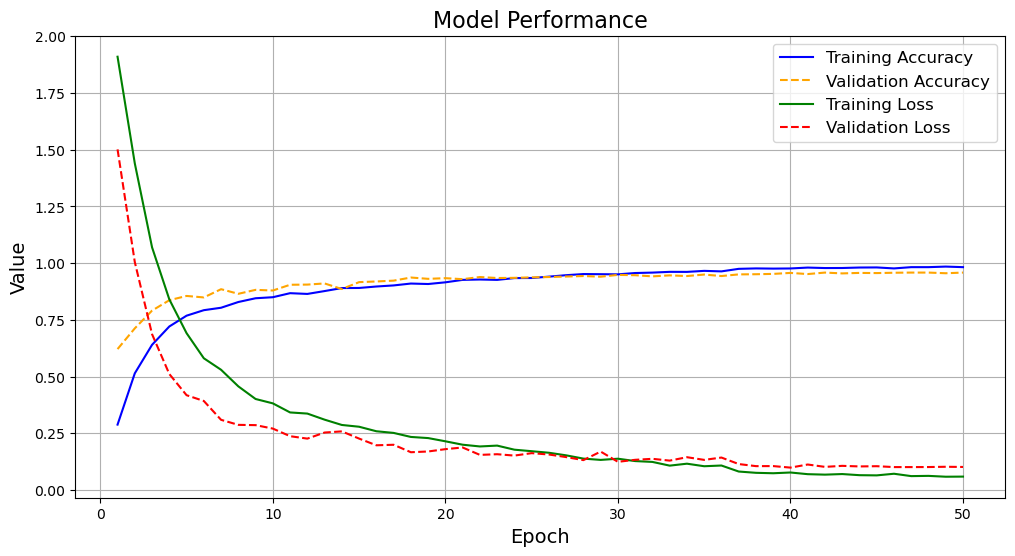

In [41]:
# Normalizamos las métricas de precisión y pérdida al rango [0, 1].
train_accuracies_normalized = [accuracy / 100 for accuracy in train_accuracies]
val_accuracies_normalized = [accuracy / 100 for accuracy in val_accuracies]
val_losses_normalized = [loss / 100 for loss in val_losses]

# Rango de valores que representan las épocas del entrenamiento. 
epochs_range = range(1, len(train_accuracies) + 1)

# Cuatro líneas que representan el comportamiento de las precisiones y pérdidas durante las épocas, tanto para entrenamiento como validación.
plt.figure(figsize=(12, 6))
plt.plot(epochs_range, train_accuracies_normalized, label='Training Accuracy', color='blue', linestyle='-')
plt.plot(epochs_range, val_accuracies_normalized, label='Validation Accuracy', color='orange', linestyle='--')
plt.plot(epochs_range, train_losses, label='Training Loss', color='green', linestyle='-')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linestyle='--')

# Titulo y ejes del gráfico
plt.title('Model Performance', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Value', fontsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True)

plt.show()